# Phishing Dataset Benchmark — Base Model Selection
Compares XGBoost, HistGradientBoosting, RandomForest, ExtraTrees across all 6 datasets.

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score
)

SEED = 42
np.random.seed(SEED)
print('All imports successful.')

/home/jn/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


All imports successful.


## Dataset Loaders

In [2]:
def load_dataset(i):
    path = f'../Dataset/dataset_{i}.csv'
    data = pd.read_csv(path)

    if i == 1:
        feature_names = list(data.columns[:-1])
        X = np.array(data[data.columns[:-1]])
        Y = np.array(data[data.columns[-1]])

    elif i == 2:
        data['status'] = [1 if x == 'phishing' else 0 for x in data['status']]
        feature_names = list(data.columns[1:-1])
        X = np.array(data[data.columns[1:-1]])
        Y = np.array(data[data.columns[-1]])

    elif i == 3:
        feature_names = list(data.columns[1:])
        X = np.array(data[data.columns[1:]])
        Y = np.array(data[data.columns[0]])

    elif i == 4:
        data['status'] = [1 if x == 'phishing' else 0 for x in data['status']]
        feature_names = list(data.columns[1:-1])
        X = np.array(data[data.columns[1:-1]])
        Y = np.array(data[data.columns[-1]])

    elif i == 5:
        feature_names = list(data.columns[1:-1])
        X = np.array(data[data.columns[1:-1]])
        Y = np.array(data[data.columns[-1]])

    elif i == 6:
        drop_cols = ['FILENAME', 'Robots', 'URLSimilarityIndex', 'TLDLegitimateProb',
                     'CharContinuationRate', 'URL', 'Domain', 'TLD', 'Title']
        drop_cols = [c for c in drop_cols if c in data.columns]
        data = data.drop(drop_cols, axis=1)
        feature_names = list(data.columns[:-1])
        X = np.array(data[data.columns[:-1]])
        Y = np.array(data[data.columns[-1]])

    else:
        raise ValueError(f'Dataset index {i} not recognized (expected 1-6).')

    print(f'  Dataset {i}: {X.shape[0]:,} samples | {X.shape[1]} features | '
          f'{100*Y.mean():.1f}% phishing')
    return X, Y, feature_names

## Model Definitions

Four models chosen for **maximum diversity** of inductive bias:
- **XGBoost** — regularized gradient boosting, column subsampling, L1/L2 penalties
- **HistGradientBoosting (sklearn)** — shrinkage-based boosting, different tree structure than XGB, slower but different bias
- **RandomForest** — bagging + random feature splits, high variance reducer
- **ExtraTrees** — extreme randomization at split points, most decorrelated from the others

Diversity of inductive bias matters more than raw power for the ensemble disagreement signal.

In [3]:
def get_models():
    return {
        'XGBoost': xgb.XGBClassifier(
            max_depth=6, n_estimators=300, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            gamma=0.1, objective='binary:logistic', eval_metric='logloss',
            random_state=SEED, verbosity=0
        ),
        'HistGradientBoosting': HistGradientBoostingClassifier(
            max_depth=6,
            max_iter=300,
            learning_rate=0.05,
            random_state=SEED
        ),
        'RandomForest': RandomForestClassifier(
            max_depth=None, n_estimators=300, max_features='sqrt',
            min_samples_leaf=3, random_state=SEED, n_jobs=-1
        ),
        'ExtraTrees': ExtraTreesClassifier(
            max_depth=None, n_estimators=300, max_features='sqrt',
            min_samples_leaf=3, random_state=SEED, n_jobs=-1
        )
    }

## Benchmark Loop
Same 70/10/20 stratified split as your existing notebooks. Metrics on **test set** only.

In [4]:
DATASET_IDS = [1, 2, 3, 4, 5, 6]
results = []

for ds_id in DATASET_IDS:
    print(f"\n{'='*62}")
    print(f'DATASET {ds_id}')
    print(f"{'='*62}")

    X, Y, feature_names = load_dataset(ds_id)

    X_train_temp, X_test, y_train_temp, y_test = train_test_split(
        X, Y, test_size=0.20, stratify=Y, random_state=SEED
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_temp, y_train_temp, test_size=0.125,
        stratify=y_train_temp, random_state=SEED
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    print(f'  Train: {X_train_s.shape} | Val: {X_val_s.shape} | Test: {X_test_s.shape}')
    print(f"\n  {'Model':<20} {'Acc':>8} {'F1':>8} {'Prec':>8} {'Recall':>8}")
    print(f"  {'-'*56}")

    models = get_models()
    for model_name, model in models.items():
        if model_name == 'XGBoost':
            model.fit(X_train_s, y_train,
                      eval_set=[(X_val_s, y_val)], verbose=False)
        else:
            model.fit(X_train_s, y_train)

        preds = model.predict(X_test_s)
        acc  = accuracy_score(y_test, preds)
        f1   = f1_score(y_test, preds)
        prec = precision_score(y_test, preds)
        rec  = recall_score(y_test, preds)

        print(f'  {model_name:<20} {acc:>8.5f} {f1:>8.5f} {prec:>8.5f} {rec:>8.5f}')
        results.append({
            'dataset': ds_id, 'model': model_name,
            'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec
        })

results_df = pd.DataFrame(results)
results_df['f1_rank'] = results_df.groupby('dataset')['f1'].rank(ascending=False, method='min')
results_df['acc_rank'] = results_df.groupby('dataset')['accuracy'].rank(ascending=False, method='min')

print('\n\nBenchmark complete.')


DATASET 1


  Dataset 1: 88,647 samples | 111 features | 34.6% phishing
  Train: (62052, 111) | Val: (8865, 111) | Test: (17730, 111)

  Model                     Acc       F1     Prec   Recall
  --------------------------------------------------------
  XGBoost               0.96543  0.95016  0.94716  0.95318
  HistGradientBoosting  0.96497  0.94947  0.94723  0.95171
  RandomForest          0.96407  0.94811  0.94680  0.94943
  ExtraTrees            0.95386  0.93480  0.91397  0.95661

DATASET 2
  Dataset 2: 19,431 samples | 84 features | 50.0% phishing
  Train: (13601, 84) | Val: (1943, 84) | Test: (3887, 84)

  Model                     Acc       F1     Prec   Recall
  --------------------------------------------------------
  XGBoost               0.97942  0.97933  0.98339  0.97530
  HistGradientBoosting  0.98225  0.98215  0.98751  0.97684
  RandomForest          0.97505  0.97498  0.97725  0.97272
  ExtraTrees            0.97144  0.97118  0.98008  0.96243

DATASET 3
  Dataset 3: 247,950 samples 

## Summary — Per-Dataset Winner + Overall Ranks

In [6]:
model_order = ['XGBoost', 'HistGradientBoosting', 'RandomForest', 'ExtraTrees']

print('\n' + '='*70)
print('SUMMARY — Best model per dataset (by F1)')
print('='*70)
print(f"{'DS':<6} {'Best Model':<20} {'Acc':>8} {'F1':>8} {'Prec':>8} {'Recall':>8}")
print('-'*70)
for ds_id in DATASET_IDS:
    sub  = results_df[results_df['dataset'] == ds_id]
    best = sub.loc[sub['f1'].idxmax()]
    print(f"DS{ds_id:<4} {best['model']:<20} {best['accuracy']:>8.5f} "
          f"{best['f1']:>8.5f} {best['precision']:>8.5f} {best['recall']:>8.5f}")

print('\n' + '='*76)
print('SUMMARY — Avg rank across all 6 datasets')
print('='*76)

rank_summary = results_df.groupby('model').agg(
    avg_f1      = ('f1',       'mean'),
    avg_accuracy= ('accuracy', 'mean'),
    avg_recall  = ('recall',   'mean'),
    avg_f1_rank = ('f1_rank',  'mean'),
    f1_std      = ('f1',       'std'),
    wins_f1     = ('f1_rank',  lambda x: (x == 1).sum()),
).reindex(model_order)

print(f"\n{'Model':<20} {'Avg F1':>8} {'Avg Acc':>9} {'Avg Rec':>9} "
      f"{'F1 Rank':>9} {'F1 Std':>9} {'Wins':>6}")
print('-'*76)
for model_name, row in rank_summary.iterrows():
    print(f"{model_name:<20} {row['avg_f1']:>8.5f} {row['avg_accuracy']:>9.5f} "
          f"{row['avg_recall']:>9.5f} {row['avg_f1_rank']:>9.2f} "
          f"{row['f1_std']:>9.5f} {int(row['wins_f1']):>5}/6")

best_base = rank_summary.sort_values(['avg_f1_rank', 'f1_std']).index[0]
print(f'\n→ Recommended base model : {best_base}')
print(f"→ Ensemble members       : {[m for m in model_order if m != best_base]}")


SUMMARY — Best model per dataset (by F1)
DS     Best Model                Acc       F1     Prec   Recall
----------------------------------------------------------------------
DS1    XGBoost               0.96543  0.95016  0.94716  0.95318
DS2    HistGradientBoosting  0.98225  0.98215  0.98751  0.97684
DS3    RandomForest          0.93589  0.93244  0.94674  0.91856
DS4    XGBoost               0.96544  0.96564  0.96021  0.97113
DS5    HistGradientBoosting  0.98750  0.98752  0.98604  0.98900
DS6    HistGradientBoosting  0.99996  0.99996  0.99993  1.00000

SUMMARY — Avg rank across all 6 datasets

Model                  Avg F1   Avg Acc   Avg Rec   F1 Rank    F1 Std   Wins
----------------------------------------------------------------------------
XGBoost               0.96255   0.96621   0.95929      1.83   0.03784     2/6
HistGradientBoosting  0.96236   0.96610   0.95868      1.83   0.03934     3/6
RandomForest          0.96586   0.96906   0.96415      2.67   0.02440     1/6
ExtraTre

## Plot 1 — F1 Heatmap + Average Bar

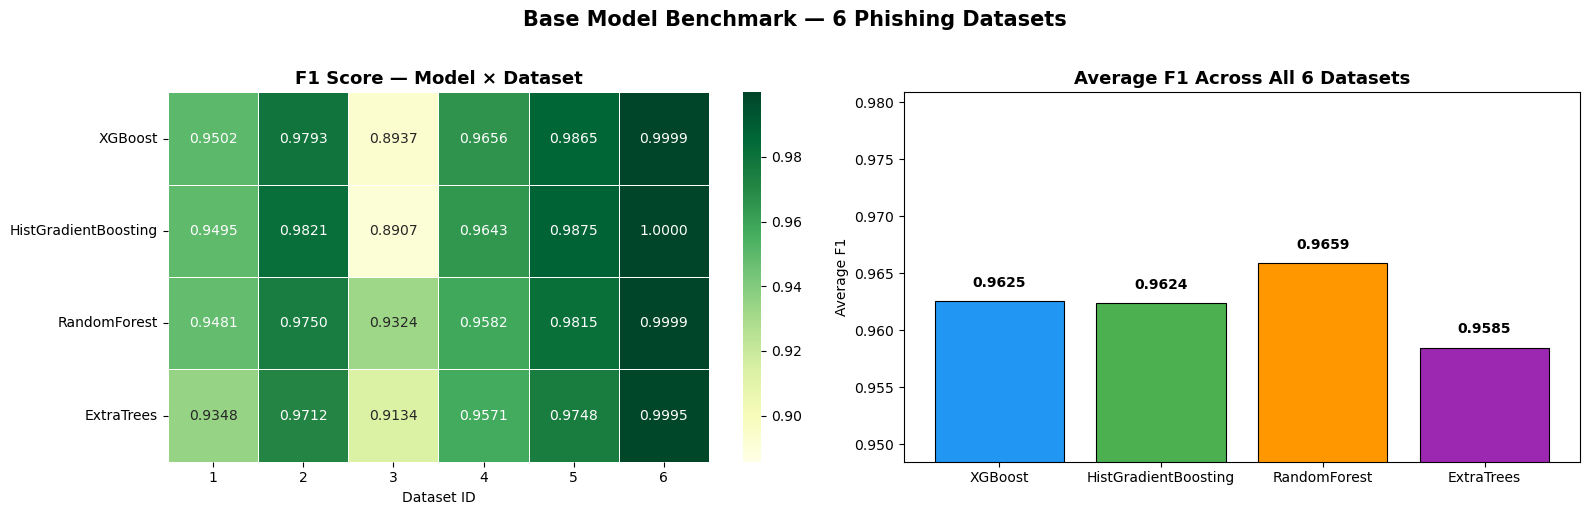

In [7]:
palette = {
    'XGBoost': '#2196F3', 'HistGradientBoosting': '#4CAF50',
    'RandomForest': '#FF9800', 'ExtraTrees': '#9C27B0'
}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_f1 = results_df.pivot(index='model', columns='dataset', values='f1').reindex(model_order)
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0],
            linewidths=0.5, vmin=pivot_f1.values.min() - 0.005)
axes[0].set_title('F1 Score — Model × Dataset', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dataset ID')
axes[0].set_ylabel('')

avg_f1 = results_df.groupby('model')['f1'].mean().reindex(model_order)
bars = axes[1].bar(avg_f1.index, avg_f1.values,
                   color=[palette[m] for m in avg_f1.index],
                   edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, avg_f1.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Average F1 Across All 6 Datasets', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average F1')
axes[1].set_ylim(avg_f1.min() - 0.01, avg_f1.max() + 0.015)

plt.suptitle('Base Model Benchmark — 6 Phishing Datasets',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Plot 2 — Consistency: F1 Score + F1 Rank Across Datasets
A flat line at rank 1 = perfectly consistent best model.

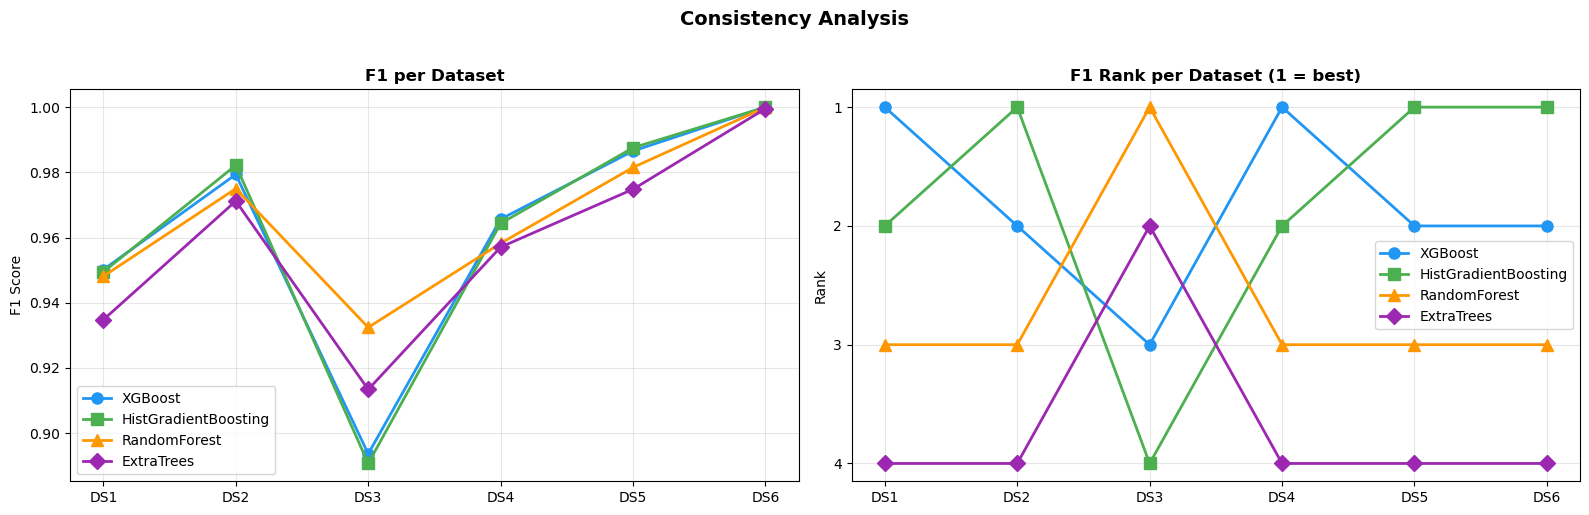

F1 std across datasets (lower = more consistent base):
------------------------------------------
  XGBoost             : 0.03784
  HistGradientBoosting: 0.03934
  RandomForest        : 0.02440
  ExtraTrees          : 0.03067


In [8]:
markers = {'XGBoost': 'o', 'HistGradientBoosting': 's', 'RandomForest': '^', 'ExtraTrees': 'D'}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for m in model_order:
    sub = results_df[results_df['model'] == m].sort_values('dataset')
    axes[0].plot(sub['dataset'], sub['f1'], marker=markers[m], label=m,
                 color=palette[m], linewidth=2, markersize=8)
    axes[1].plot(sub['dataset'], sub['f1_rank'], marker=markers[m], label=m,
                 color=palette[m], linewidth=2, markersize=8)

for ax, title, ylabel in zip(axes,
    ['F1 per Dataset', 'F1 Rank per Dataset (1 = best)'],
    ['F1 Score', 'Rank']):
    ax.set_xticks(DATASET_IDS)
    ax.set_xticklabels([f'DS{i}' for i in DATASET_IDS])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
axes[1].invert_yaxis()
axes[1].set_yticks([1, 2, 3, 4])

plt.suptitle('Consistency Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('F1 std across datasets (lower = more consistent base):')
print('-' * 42)
for m in model_order:
    print(f"  {m:<20}: {results_df[results_df['model']==m]['f1'].std():.5f}")

## Plot 3 — Full Metrics Grid

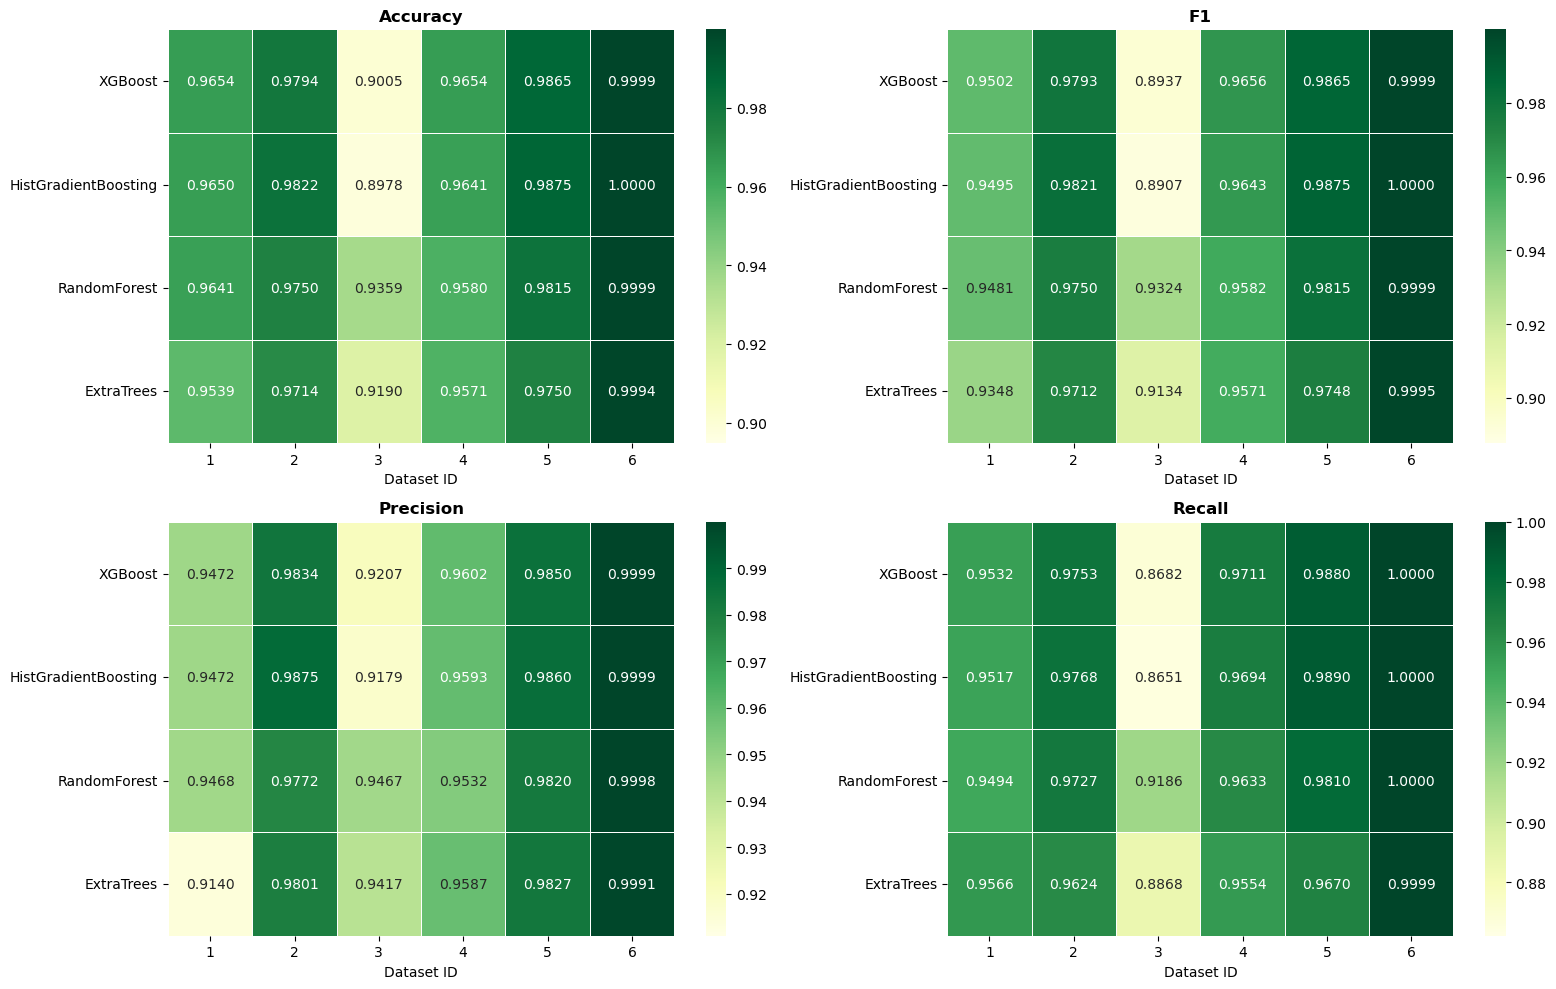

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, metric in zip(axes.flatten(), ['accuracy', 'f1', 'precision', 'recall']):
    pivot = results_df.pivot(index='model', columns='dataset', values=metric).reindex(model_order)
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
                linewidths=0.5, vmin=pivot.values.min() - 0.003)
    ax.set_title(metric.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Dataset ID')
    ax.set_ylabel('')
# plt.suptitle('Full Metrics Grid — All Models × All Datasets',
            #  fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Final Decision

In [11]:
final = results_df.groupby('model').agg(
    avg_f1      = ('f1',       'mean'),
    avg_acc     = ('accuracy', 'mean'),
    avg_recall  = ('recall',   'mean'),
    f1_std      = ('f1',       'std'),
    avg_f1_rank = ('f1_rank',  'mean'),
    wins        = ('f1_rank',  lambda x: (x == 1).sum()),
).reindex(model_order)

best_base     = final.sort_values(['avg_f1_rank', 'f1_std']).index[0]
ensemble_mbrs = [m for m in model_order if m != best_base]

print('='*76)
print('FINAL DECISION')
print('='*76)
print(f"\n{'Model':<20} {'Avg F1':>8} {'Avg Acc':>9} {'Avg Rec':>9} "
      f"{'F1 Rank':>9} {'F1 Std':>9} {'Wins':>8}")
print('-'*76)
for model_name, row in final.iterrows():
    tag = ' <- BASE' if model_name == best_base else ''
    print(f"{model_name:<20} {row['avg_f1']:>8.5f} {row['avg_acc']:>9.5f} "
          f"{row['avg_recall']:>9.5f} {row['avg_f1_rank']:>9.2f} "
          f"{row['f1_std']:>9.5f} {int(row['wins']):>5}/6{tag}")

print(f"""
→ BASE MODEL      : {best_base}
→ ENSEMBLE MEMBERS: {ensemble_mbrs}
""")

FINAL DECISION

Model                  Avg F1   Avg Acc   Avg Rec   F1 Rank    F1 Std     Wins
----------------------------------------------------------------------------
XGBoost               0.96255   0.96621   0.95929      1.83   0.03784     2/6 <- BASE
HistGradientBoosting  0.96236   0.96610   0.95868      1.83   0.03934     3/6
RandomForest          0.96586   0.96906   0.96415      2.67   0.02440     1/6
ExtraTrees            0.95846   0.96265   0.95468      3.67   0.03067     0/6

→ BASE MODEL      : XGBoost
→ ENSEMBLE MEMBERS: ['HistGradientBoosting', 'RandomForest', 'ExtraTrees']

